# Entity-Matching Model Evaluation

This notebook compares several scikit-learn classifiers on the generated pairwise similarity features. The target is `is_same`; entity identifiers are retained only for group-aware splitting and are never used as model features.

The split follows the project convention: rows from the same `s1_entity_id` stay in one partition to reduce leakage. Because this is a precision-heavy matching task, the main ranking metric is $F_{0.5}$, with precision, recall, ROC-AUC, average precision, and confusion matrices reported as supporting diagnostics.

## Setup

The notebook expects the files at `src/blocking_results/experiment2_train.tsv` and `src/blocking_results/experiment2_test.tsv`. Run the next cell only if the dependencies are missing.

In [1]:
# Uncomment once in a fresh environment if needed:
# %pip install pandas numpy scikit-learn matplotlib seaborn

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
BETA = 0.5
DATA_DIR = Path.cwd() / "blocking_results"
if not DATA_DIR.exists():
    DATA_DIR = Path.cwd() / "src" / "blocking_results"

TRAIN_PATH = DATA_DIR / "experiment2_train.tsv"
TEST_PATH = DATA_DIR / "experiment2_test.tsv"
assert TRAIN_PATH.exists(), f"Training file not found: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"Test file not found: {TEST_PATH}"

train_df = pd.read_csv(TRAIN_PATH, sep="\t")
test_df = pd.read_csv(TEST_PATH, sep="\t")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
display(train_df.head())

Train shape: (11006, 25)
Test shape:  (2798, 25)


,name_exact,address_exact,full_exact,name_token_jaccard,address_token_jaccard,full_token_jaccard,name_levenshtein,address_levenshtein,full_levenshtein,name_token_set_ratio,...,address_left_length,address_right_length,name_left_tokens,name_right_tokens,address_left_tokens,address_right_tokens,same_country,s1_entity_id,candidate_entity_id,is_same
0,0,0,0,0.333333,0.000000,0.057143,0.610169,0.382979,0.485149,0.722222,...,76,65,3,5,17,15,1,S1-372675685,S3-622431512,0
1,0,0,0,0.111111,0.000000,0.052632,0.444444,0.363636,0.412214,0.539683,...,35,31,6,4,6,6,1,S1-441023683,S2-353969853,0
2,0,0,0,0.200000,0.000000,0.066667,0.411765,0.412698,0.424242,0.588235,...,30,33,4,2,5,5,1,S1-476097182,S2-106429445,0
3,0,0,0,0.666667,0.714286,0.692308,0.714286,0.967742,0.850000,0.857143,...,30,32,5,5,6,6,1,S1-455886423,S2-401166227,1
4,0,0,0,0.285714,0.057143,0.095238,0.766667,0.356808,0.450909,0.766667,...,119,94,4,5,22,19,1,S1-623858923,S3-415626034,0


In [2]:
TARGET = "is_same"
GROUP = "s1_entity_id"
ID_COLUMNS = ["s1_entity_id", "candidate_entity_id"]
FEATURE_COLUMNS = [
    column for column in train_df.columns
    if column not in ID_COLUMNS + [TARGET]
]

missing_in_test = sorted(set(FEATURE_COLUMNS + [TARGET]) - set(test_df.columns))
if missing_in_test:
    raise ValueError(f"Test data is missing columns: {missing_in_test}")

X_full = train_df[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
y_full = train_df[TARGET].astype(int)
groups = train_df[GROUP].astype(str)
X_test = test_df[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
y_test = test_df[TARGET].astype(int)

print(f"Features used: {len(FEATURE_COLUMNS)}")
print(f"Positive rate in train: {y_full.mean():.3f}")
print(f"Positive rate in test:  {y_test.mean():.3f}")
display(pd.DataFrame({"dtype": X_full.dtypes, "missing": X_full.isna().sum()}))

Features used: 22
Positive rate in train: 0.252
Positive rate in test:  0.243


,dtype,missing
name_exact,int64,0
address_exact,int64,0
full_exact,int64,0
name_token_jaccard,float64,0
address_token_jaccard,float64,0
full_token_jaccard,float64,0
name_levenshtein,float64,0
address_levenshtein,float64,0
full_levenshtein,float64,0
name_token_set_ratio,float64,0


## Group-aware validation split

The supplied test file remains untouched for the final comparison. A group-aware validation subset is taken from the training file for threshold selection and quick model diagnostics.

In [3]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, valid_idx = next(splitter.split(X_full, y_full, groups=groups))

X_train = X_full.iloc[train_idx].reset_index(drop=True)
y_train = y_full.iloc[train_idx].reset_index(drop=True)
X_valid = X_full.iloc[valid_idx].reset_index(drop=True)
y_valid = y_full.iloc[valid_idx].reset_index(drop=True)

print(f"Model-train rows: {len(X_train):,}; groups: {groups.iloc[train_idx].nunique():,}")
print(f"Validation rows:  {len(X_valid):,}; groups: {groups.iloc[valid_idx].nunique():,}")
print(f"Group overlap: {len(set(groups.iloc[train_idx]) & set(groups.iloc[valid_idx]))}")

Model-train rows: 8,760; groups: 639
Validation rows:  2,246; groups: 160
Group overlap: 0


## Candidate models

These models cover a linear baseline, nonlinear tree ensembles, histogram gradient boosting, and a kernel classifier. Class weighting is enabled where supported so the comparison remains useful if the positive/negative ratio changes.

In [4]:
def numeric_pipeline(estimator, scale=False):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    return Pipeline(steps)

models = {
    "logistic_regression": numeric_pipeline(
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        scale=True,
    ),
    "random_forest": numeric_pipeline(
        RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    ),
    "extra_trees": numeric_pipeline(
        ExtraTreesClassifier(
            n_estimators=300, min_samples_leaf=2, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    ),
    "hist_gradient_boosting": numeric_pipeline(
        HistGradientBoostingClassifier(
            max_iter=250, learning_rate=0.08, max_leaf_nodes=31,
            l2_regularization=1.0, random_state=RANDOM_STATE,
        )
    ),
    "rbf_svm": numeric_pipeline(
        SVC(C=2.0, gamma="scale", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
        scale=True,
    ),
}
list(models)

['logistic_regression',
 'random_forest',
 'extra_trees',
 'hist_gradient_boosting',
 'rbf_svm']

In [5]:
def probabilities_and_predictions(model, X, threshold=0.5):
    probabilities = model.predict_proba(X)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    return probabilities, predictions

def score_predictions(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "threshold": threshold,
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f0.5": fbeta_score(y_true, predictions, beta=BETA, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
    }

def choose_f05_threshold(y_true, probabilities):
    thresholds = np.unique(np.r_[0.0, probabilities, 1.0])
    scores = [score_predictions(y_true, probabilities, threshold)["f0.5"] for threshold in thresholds]
    best_index = int(np.argmax(scores))
    return float(thresholds[best_index]), float(scores[best_index])

validation_models = {}
validation_rows = []
for name, model in models.items():
    fitted = clone(model).fit(X_train, y_train)
    probabilities, _ = probabilities_and_predictions(fitted, X_valid)
    threshold, _ = choose_f05_threshold(y_valid, probabilities)
    row = {"model": name, **score_predictions(y_valid, probabilities, threshold)}
    validation_rows.append(row)
    validation_models[name] = (fitted, threshold)

validation_results = pd.DataFrame(validation_rows).sort_values("f0.5", ascending=False)
display(validation_results.style.format({column: "{:.4f}" for column in validation_results.columns if column != "model"}))

c:\Users\Prashant Suthar\Desktop\ML PROJECT\Extracter Folder\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,threshold,precision,recall,f0.5,roc_auc,average_precision
2,extra_trees,0.7219,0.9982,0.9862,0.9958,0.9995,0.9989
3,hist_gradient_boosting,0.7924,0.9982,0.9862,0.9958,0.9997,0.9991
1,random_forest,0.7702,0.9982,0.9810,0.9947,0.9996,0.9991
0,logistic_regression,0.8939,0.9982,0.9775,0.9940,0.9995,0.9989
4,rbf_svm,0.7720,0.9948,0.9844,0.9927,0.9994,0.9987


## Validation diagnostics

The threshold is selected on validation data for $F_{0.5}$ rather than assuming the default 0.5 cutoff. This is especially important when false positives are more costly than false negatives.

Best validation model: extra_trees
Selected threshold: 0.7219
              precision    recall  f1-score   support

           0     0.9952    0.9994    0.9973      1668
           1     0.9982    0.9862    0.9922       578

    accuracy                         0.9960      2246
   macro avg     0.9967    0.9928    0.9947      2246
weighted avg     0.9960    0.9960    0.9960      2246



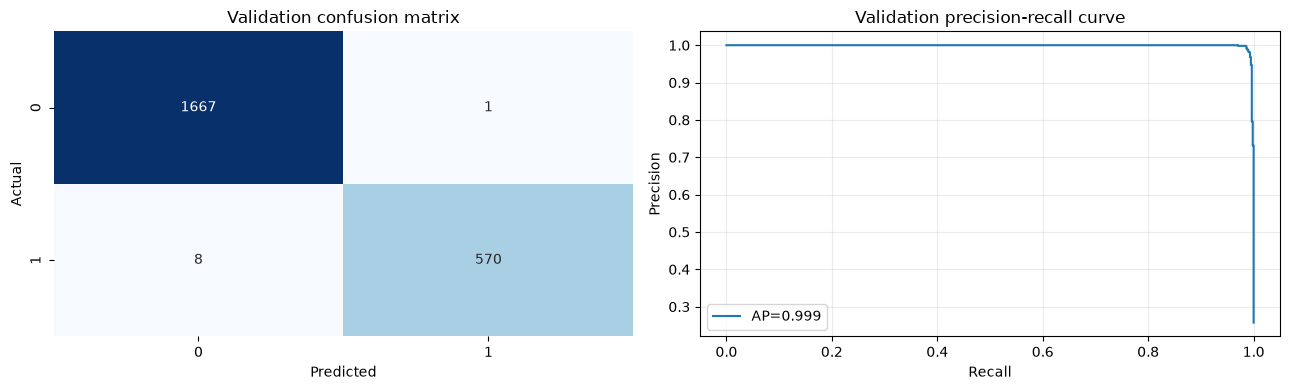

In [6]:
best_validation_model_name = validation_results.iloc[0]["model"]
best_validation_model, best_threshold = validation_models[best_validation_model_name]
print(f"Best validation model: {best_validation_model_name}")
print(f"Selected threshold: {best_threshold:.4f}")

valid_probabilities, valid_predictions = probabilities_and_predictions(
    best_validation_model, X_valid, threshold=best_threshold
)
print(classification_report(y_valid, valid_predictions, digits=4, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cm = confusion_matrix(y_valid, valid_predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Validation confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

precision, recall, _ = precision_recall_curve(y_valid, valid_probabilities)
axes[1].plot(recall, precision, label=f"AP={average_precision_score(y_valid, valid_probabilities):.3f}")
axes[1].set_title("Validation precision-recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()

## Final comparison on the supplied test split

Each model is refit on all rows in `experiment2_train.tsv`. Its threshold is selected on the validation split above, then evaluated once on `experiment2_test.tsv`.

In [7]:
test_rows = []
fitted_test_models = {}
for name, model in models.items():
    fitted = clone(model).fit(X_full, y_full)
    threshold = validation_models[name][1]
    probabilities, predictions = probabilities_and_predictions(fitted, X_test, threshold)
    test_rows.append({"model": name, **score_predictions(y_test, probabilities, threshold)})
    fitted_test_models[name] = (fitted, threshold)

test_results = pd.DataFrame(test_rows).sort_values("f0.5", ascending=False).reset_index(drop=True)
display(test_results.style.format({column: "{:.4f}" for column in test_results.columns if column != "model"}))

c:\Users\Prashant Suthar\Desktop\ML PROJECT\Extracter Folder\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,threshold,precision,recall,f0.5,roc_auc,average_precision
0,rbf_svm,0.7720,0.9926,0.9823,0.9905,0.9997,0.9991
1,logistic_regression,0.8939,0.9940,0.9720,0.9895,0.9998,0.9994
2,hist_gradient_boosting,0.7924,0.9939,0.9676,0.9886,0.9997,0.9991
3,extra_trees,0.7219,0.9939,0.9647,0.9879,0.9998,0.9994
4,random_forest,0.7702,0.9924,0.9617,0.9861,0.9997,0.9992


Best test model by F0.5: rbf_svm
Threshold: 0.7720
              precision    recall  f1-score   support

           0     0.9944    0.9976    0.9960      2119
           1     0.9926    0.9823    0.9874       679

    accuracy                         0.9939      2798
   macro avg     0.9935    0.9900    0.9917      2798
weighted avg     0.9939    0.9939    0.9939      2798



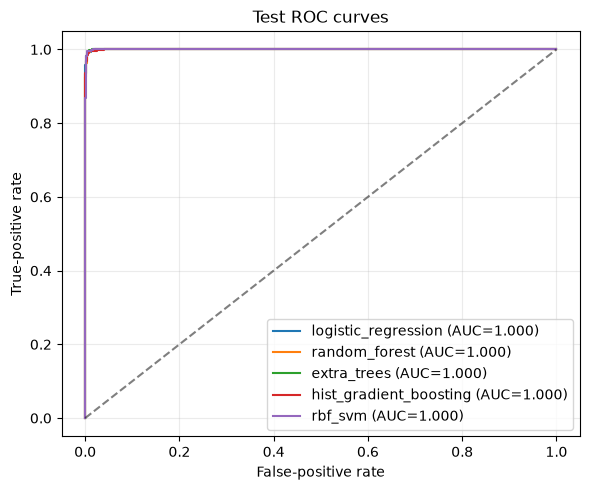

In [8]:
best_test_model_name = test_results.iloc[0]["model"]
best_test_model, best_test_threshold = fitted_test_models[best_test_model_name]
test_probabilities, test_predictions = probabilities_and_predictions(
    best_test_model, X_test, threshold=best_test_threshold
)
print(f"Best test model by F0.5: {best_test_model_name}")
print(f"Threshold: {best_test_threshold:.4f}")
print(classification_report(y_test, test_predictions, digits=4, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
for name, (fitted, threshold) in fitted_test_models.items():
    probabilities, _ = probabilities_and_predictions(fitted, X_test)
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    ax.plot(false_positive_rate, true_positive_rate, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_title("Test ROC curves")
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

## Optional next steps

- Tune the strongest two models with `RandomizedSearchCV` and a group-aware cross-validation splitter.
- Inspect false positives and false negatives by `s1_entity_id` and source prefix.
- Export predictions only after choosing a threshold against the desired precision/recall trade-off.
- For final challenge submission, apply the fitted model to candidate pairs from the test blocking stage and format IDs with the submission validator.